## Projet IA   
L’agriculture de précision s’appuie aujourd’hui sur l’IA et le Deep Learning (DL) pour détecter rapidement les maladies des cultures. L’objectif de ce mini-projet est de développer un système automatique basé sur un réseau de neurones convolutif (CNN) capable de distinguer une feuille de pomme de terre saine d’une feuille malade, sans tenir compte du type de maladie.

In [1]:
#importation des bibliotheque
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, f1_score

# ==============================================================================
# 0. CONFIGURATION DES CHEMINS
# ==============================================================================

In [ ]:
# Si vous rencontrez encore une erreur "FileNotFoundError", remplacez './Potato' 
# par votre chemin absolu, par exemple : r"C:\Users\nzigu\...\UA3_IA\Potato"
base_dir = '.' 
binary_dataset_dir = os.path.join(base_dir, 'Binary_Potato_Dataset')

print("=== DÉMARRAGE DU PIPELINE ===")



=== DÉMARRAGE DU PIPELINE ===


# ==============================================================================
# 1. PRÉTRAITEMENT ET FUSION DES CLASSES (CLASSIFICATION BINAIRE)
# ==============================================================================


In [4]:
print("\n1. Réorganisation des dossiers...")
splits = ['Train', 'Valid', 'Test']

for split in splits:
    split_path = os.path.join(base_dir, split)
    if not os.path.exists(split_path): 
        print(f"  -> Dossier ignoré (introuvable) : {split_path}")
        continue

    # Création des sous-dossiers binaires
    dest_0 = os.path.join(binary_dataset_dir, split, '0_Healthy')
    dest_1 = os.path.join(binary_dataset_dir, split, '1_Diseased')
    os.makedirs(dest_0, exist_ok=True)
    os.makedirs(dest_1, exist_ok=True)

    # Parcours des classes et fusion
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path): continue

        # healthy va dans 0_Healthy, le reste (Early/Late blight) va dans 1_Diseased
        target_dir = dest_0 if 'healthy' in class_name.lower() else dest_1

        for img in os.listdir(class_path):
            src_img = os.path.join(class_path, img)
            dst_img = os.path.join(target_dir, img)
            if not os.path.exists(dst_img):
                shutil.copy(src_img, dst_img)
                
print("  -> Dossiers binaires prêts.")


1. Réorganisation des dossiers...
  -> Dossiers binaires prêts.


# ==============================================================================
# 2. CHARGEMENT ET NORMALISATION DES DONNÉES
# ==============================================================================

In [5]:
print("\n2. Chargement des images en mémoire...")
BATCH_SIZE = 32
IMAGE_SIZE = (256, 256)

train_dir = os.path.join(binary_dataset_dir, 'Train')
valid_dir = os.path.join(binary_dataset_dir, 'Valid')

# Chargement direct via tf.keras.utils
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

# Normalisation des pixels (0 à 1)
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))


2. Chargement des images en mémoire...
Found 900 files belonging to 2 classes.
Found 300 files belonging to 2 classes.


In [6]:
# ==============================================================================
# 3. CONSTRUCTION DU MODÈLE CNN
# ==============================================================================
print("\n3. Construction du modèle CNN...")
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ajout de Dropout pour l'amélioration
    
    layers.Dense(1, activation='sigmoid') # Sigmoïde pour la classification binaire
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


3. Construction du modèle CNN...


# ==============================================================================
# 4. ENTRAÎNEMENT
# ==============================================================================

In [7]:
print("\n4. Début de l'entraînement...")
EPOCHS = 10 

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)


4. Début de l'entraînement...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step - accuracy: 0.6389 - loss: 0.7203 - val_accuracy: 0.6900 - val_loss: 0.3656
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 258ms/step - accuracy: 0.8800 - loss: 0.2842 - val_accuracy: 0.7467 - val_loss: 0.4328
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - accuracy: 0.9100 - loss: 0.2222 - val_accuracy: 0.9533 - val_loss: 0.1521
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 257ms/step - accuracy: 0.9522 - loss: 0.1211 - val_accuracy: 0.9467 - val_loss: 0.1274
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step - accuracy: 0.9289 - loss: 0.1881 - val_accuracy: 0.9533 - val_loss: 0.1081
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.9567 - loss: 0.1200 - val_accuracy: 0.9533 - val_loss: 0.1085
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step - accuracy: 0.9333 - loss: 0.1628 - val_accuracy: 0.9633 - val_loss: 0.1875
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - accuracy: 0.9456 - 

# ==============================================================================
# 5. ÉVALUATION ET COURBES D'APPRENTISSAGE
# ==============================================================================


5. Affichage des résultats...


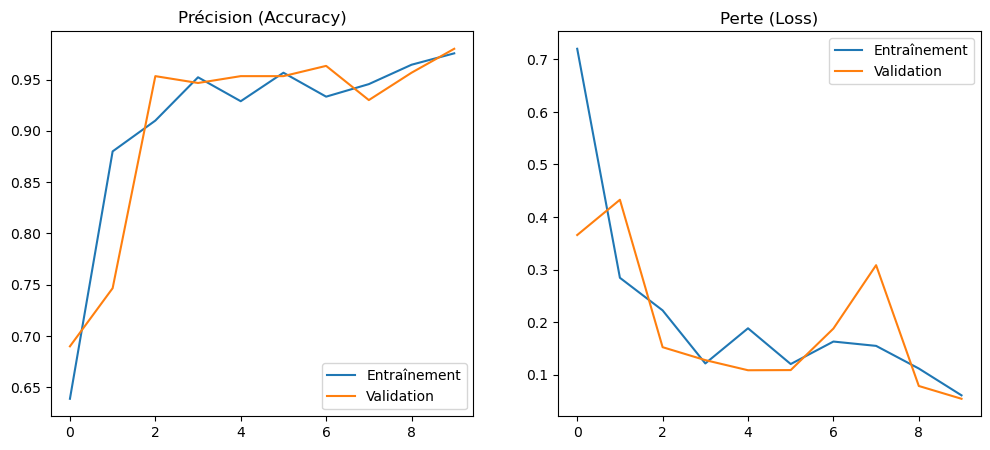

In [8]:
print("\n5. Affichage des résultats...")
# Récupération des données de l'historique
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

# Création du graphique
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement')
plt.plot(epochs_range, val_acc, label='Validation')
plt.legend(loc='lower right')
plt.title('Précision (Accuracy)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement')
plt.plot(epochs_range, val_loss, label='Validation')
plt.legend(loc='upper right')
plt.title('Perte (Loss)')
plt.show()

# ==============================================================================
# 6. CALCUL DU F1-SCORE
# ==============================================================================

In [9]:
y_true = []
y_pred_probs = []

for images, labels in val_dataset:
    y_true.extend(labels.numpy().flatten())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_pred = np.array([1 if p > 0.5 else 0 for p in y_pred_probs])

print("\n=== RAPPORT FINAL ===")
print(classification_report(y_true, y_pred, target_names=['Saine - 0', 'Malade - 1']))
print(f"F1-Score Global : {f1_score(y_true, y_pred):.4f}")


=== RAPPORT FINAL ===
              precision    recall  f1-score   support

   Saine - 0       0.96      0.98      0.97       100
  Malade - 1       0.99      0.98      0.98       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

F1-Score Global : 0.9849


# ==============================================================================
# 7. ÉVALUATION FINALE SUR LE DATASET DE TEST
# ==============================================================================

In [10]:
print("\n=== ÉVALUATION SUR LES DONNÉES DE TEST ===")

# 1. Définition du chemin vers le dossier Test binaire
test_dir = os.path.join(binary_dataset_dir, 'Test')

# 2. Chargement du dataset de Test
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, 
    image_size=IMAGE_SIZE, 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=False # On ne mélange pas pour garder l'ordre des vraies étiquettes
)

# 3. Normalisation (Très important : appliquer la même transformation qu'à l'entraînement)
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# 4. Évaluation globale (Loss et Accuracy)
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"\nPrécision (Accuracy) sur le Test : {test_acc*100:.2f}%")
print(f"Perte (Loss) sur le Test : {test_loss:.4f}")

# 5. Calcul détaillé du F1-Score sur le Test
y_true_test = []
y_pred_probs_test = []

for images, labels in test_dataset:
    y_true_test.extend(labels.numpy().flatten())
    preds = model.predict(images, verbose=0)
    y_pred_probs_test.extend(preds.flatten())

# Seuil de 0.5 pour la classification binaire
y_pred_test = np.array([1 if p > 0.5 else 0 for p in y_pred_probs_test])

print("\n=== RAPPORT DE CLASSIFICATION (TEST) ===")
print(classification_report(y_true_test, y_pred_test, target_names=['Saine - 0', 'Malade - 1']))
print(f"F1-Score Global (Test) : {f1_score(y_true_test, y_pred_test):.4f}")


=== ÉVALUATION SUR LES DONNÉES DE TEST ===
Found 1200 files belonging to 2 classes.
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.7358 - loss: 1.3880

Précision (Accuracy) sur le Test : 73.58%
Perte (Loss) sur le Test : 1.3880

=== RAPPORT DE CLASSIFICATION (TEST) ===
              precision    recall  f1-score   support

   Saine - 0       0.24      0.98      0.38       100
  Malade - 1       1.00      0.71      0.83      1100

    accuracy                           0.74      1200
   macro avg       0.62      0.85      0.61      1200
weighted avg       0.93      0.74      0.79      1200

F1-Score Global (Test) : 0.8320
